# Week 5 Assignment: Latent Diffusion, DDIM & CFG

**24th Computer Vision Basic Session / KUBIG / made by Junyoung Park**

---

강의의 DDPM, DDIM, Classifier-Free Guidance(CFG), Latent Diffusion을 하나의 작은 생성 파이프라인으로 연결합니다.
`TODO`의 `...`로 표시된 핵심 부분만 채우고, 노트북을 위에서부터 아래까지 **끊김 없이 실행**한 뒤 출력이 남은 상태로 제출하세요.

### 구현 항목 (TODO 1~8)

| 번호 | 위치 | 내용 |
|---|---|---|
| TODO 1 | Latent 전처리 | latent 정규화와 역정규화 |
| TODO 2 | Diffusion schedule | `alphas`, `alphas_cumprod` |
| TODO 3 | `q_sample` | DDPM forward process의 closed form |
| TODO 4 | `diffusion_loss` | condition dropout을 포함한 CFG 학습 |
| TODO 5 | `predict_noise_cfg` | conditional/unconditional 예측 결합 |
| TODO 6 | `predict_x0_from_eps` | noise 예측으로부터 clean latent 복원 |
| TODO 7 | `ddim_step` | DDIM의 `sigma_t` 계산 |
| TODO 8 | `ddim_step` | DDIM 방향항과 한 스텝 update |

마지막에는 수업 내용을 다음 주 주제와 연결해 보고, 각자의 생각을 작성하는 질문 하나가 있습니다.

### 실행 시간과 환경

- **Google Colab T4 GPU 기준**으로 설계되었습니다. 기본 설정의 전체 학습 목표 시간은 약 1~3분이며, 런타임 상황에 따라 더 걸릴 수 있습니다.
- CPU는 정식 실행 환경이 아닙니다. 코드 구조만 빠르게 확인하려면 환경 설정 전에 `CV_W5_QUICK_MODE=1`을 지정할 수 있지만, 생성 품질은 평가하지 마세요.
- 외부 pretrained diffusion 모델이나 대용량 다운로드를 사용하지 않습니다. MNIST만 내려받습니다.

### 제출

- 실행 결과가 포함된 `.ipynb` 파일
- 파일명에서 `00기_000`을 본인의 기수와 이름으로 변경
- `KUBIG_26_FALL/Basic Study/CV/week5`
- 마감: 운영진 공지 확인

## 0. 환경 설정

Colab에서 `런타임 > 런타임 유형 변경 > T4 GPU`를 선택한 뒤 실행하세요.
아래 기본 설정은 결과 품질과 실행 시간 사이의 절충안입니다.

In [1]:
import copy
import math
import os
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision import datasets, transforms
from torchvision.utils import make_grid

SEED = 42
QUICK_MODE = os.getenv("CV_W5_QUICK_MODE", "0") == "1"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if QUICK_MODE:
    DATA_SIZE, AE_EPOCHS, DIFF_TRAIN_STEPS = 5_000, 1, 60
else:
    DATA_SIZE, AE_EPOCHS, DIFF_TRAIN_STEPS = 20_000, 5, 3_000

BATCH_SIZE = 256
LATENT_CHANNELS = 4
DIFF_TIMESTEPS = 200
NULL_LABEL = 10                 # 0~9가 실제 class, 10은 condition이 없는 상태
COND_DROP_PROB = 0.15

print("torch version:", torch.__version__)
print("device:", device)
print("quick mode:", QUICK_MODE)
print(f"data={DATA_SIZE:,}, AE epochs={AE_EPOCHS}, diffusion updates={DIFF_TRAIN_STEPS:,}")
if device.type != "cuda" and not QUICK_MODE:
    print("[주의] 기본 설정은 T4 GPU용입니다. CPU에서는 오래 걸릴 수 있습니다.")

torch version: 2.13.0
device: cpu
quick mode: False
data=20,000, AE epochs=5, diffusion updates=3,000
[주의] 기본 설정은 T4 GPU용입니다. CPU에서는 오래 걸릴 수 있습니다.


In [2]:
def show_images(images, title="", nrow=10):
    images = images.detach().cpu().clamp(0, 1)
    grid = make_grid(images, nrow=nrow, padding=2)
    plt.figure(figsize=(nrow, math.ceil(len(images) / nrow) + 0.8))
    plt.imshow(grid.permute(1, 2, 0).squeeze(), cmap="gray", vmin=0, vmax=1)
    plt.title(title)
    plt.axis("off")
    plt.show()


def sync_time():
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    return time.perf_counter()

## 1. 데이터와 작은 Autoencoder

실제 LDM은 먼저 학습된 encoder $E$로 이미지 $x$를 작은 latent $z=E(x)$로 바꾸고, diffusion을 픽셀 대신 latent에서 수행합니다.
마지막에는 decoder $D$가 생성된 latent를 이미지로 되돌립니다.

이 과제에서는 구조를 빠르게 확인하기 위해 MNIST와 작은 convolutional autoencoder를 사용합니다.
`1×28×28 = 784`개의 픽셀을 `4×7×7 = 196`개의 latent 원소로 압축합니다.

100.0%
100.0%
100.0%
100.0%

train subset: 20000 | batches: 78


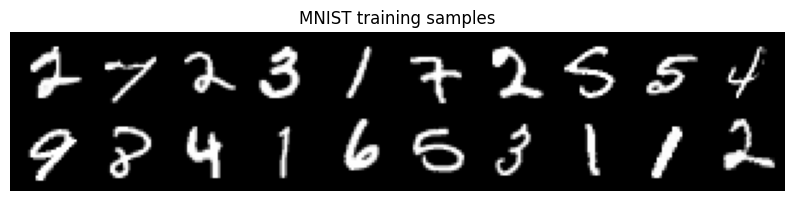

In [3]:
tf = transforms.ToTensor()
full_train = datasets.MNIST(root="./data", train=True, download=True, transform=tf)
test_set = datasets.MNIST(root="./data", train=False, download=True, transform=tf)

subset_generator = torch.Generator().manual_seed(SEED)
subset_idx = torch.randperm(len(full_train), generator=subset_generator)[:DATA_SIZE].tolist()
train_set = Subset(full_train, subset_idx)

loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": 2 if device.type == "cuda" else 0,
    "pin_memory": device.type == "cuda",
}
ae_loader = DataLoader(train_set, shuffle=True, drop_last=True, **loader_kwargs)
test_loader = DataLoader(test_set, shuffle=False, **loader_kwargs)

x_preview, y_preview = next(iter(ae_loader))
print("train subset:", len(train_set), "| batches:", len(ae_loader))
show_images(x_preview[:20], "MNIST training samples", nrow=10)

In [ ]:
# 1x28x28 to 4x7x7 (4 채널)
class TinyAutoencoder(nn.Module):
    def __init__(self, latent_channels=LATENT_CHANNELS):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),      # 28 -> 14
            nn.SiLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),     # 14 -> 7
            nn.SiLU(),
            nn.Conv2d(32, latent_channels, 3, padding=1),  # 4 x 7 x 7
        )
        self.decoder = nn.Sequential(
            nn.Conv2d(latent_channels, 32, 3, padding=1),
            nn.SiLU(),
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1),  # 7 -> 14
            nn.SiLU(),
            nn.ConvTranspose2d(16, 1, 4, stride=2, padding=1),   # 14 -> 28
        )

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return torch.sigmoid(self.decoder(z))

    def forward(self, x):
        return self.decode(self.encode(x))


autoencoder = TinyAutoencoder().to(device)
ae_optimizer = torch.optim.Adam(autoencoder.parameters(), lr=2e-3)

ae_history = []
ae_start = sync_time()
for epoch in range(1, AE_EPOCHS + 1):
    autoencoder.train()
    running = 0.0
    for x, _ in ae_loader:
        x = x.to(device, non_blocking=True)
        recon = autoencoder(x)
        loss = F.binary_cross_entropy(recon, x)

        ae_optimizer.zero_grad()
        loss.backward()
        ae_optimizer.step()
        running += loss.item()

    epoch_loss = running / len(ae_loader)
    ae_history.append(epoch_loss)
    print(f"[AE] epoch {epoch:02d}/{AE_EPOCHS} | BCE {epoch_loss:.4f}")

ae_seconds = sync_time() - ae_start
print(f"AE training time: {ae_seconds:.1f}s")

[AE] epoch 01/5 | BCE 0.3831
[AE] epoch 02/5 | BCE 0.1471
[AE] epoch 03/5 | BCE 0.1018
[AE] epoch 04/5 | BCE 0.0872
[AE] epoch 05/5 | BCE 0.0809
AE training time: 22.7s


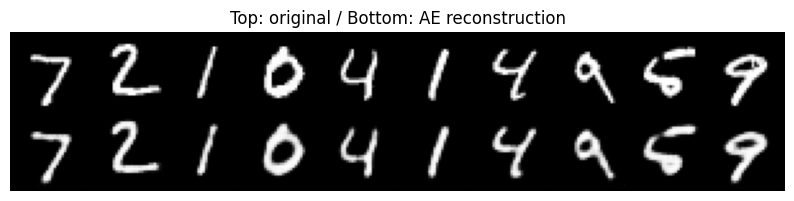

pixel elements per sample : 784
latent elements per sample: 196
element-count compression  : 4.0x


In [5]:
autoencoder.eval()
x_test, _ = next(iter(test_loader))
x_test = x_test[:10].to(device)
with torch.no_grad():
    x_recon = autoencoder(x_test)

show_images(torch.cat([x_test, x_recon]), "Top: original / Bottom: AE reconstruction", nrow=10)

pixel_elements = 1 * 28 * 28
latent_elements = LATENT_CHANNELS * 7 * 7
print("pixel elements per sample :", pixel_elements)
print("latent elements per sample:", latent_elements)
print(f"element-count compression  : {pixel_elements / latent_elements:.1f}x")

## 2. Latent dataset

Autoencoder를 freeze하고 전체 학습 이미지를 한 번만 encode합니다. 이후 denoiser는 픽셀을 보지 않고 latent만 사용합니다.

채널별 scale이 크게 다르면 noise prediction이 불안정해질 수 있으므로 각 latent channel을 평균 0, 표준편차 1로 맞춥니다.

### TODO 1: Latent 정규화

다음을 구현하세요.

$$z_{norm} = \frac{z-\mu}{\sigma}, \qquad z = z_{norm}\sigma+\mu$$

`latent_mean`, `latent_std`는 `(1, C, 1, 1)` shape입니다. 입력과 device가 다를 수 있다는 점에 주의하세요.

In [ ]:
# freeze autoencoder 
autoencoder.eval()
latent_chunks, label_chunks = [], []
encode_loader = DataLoader(train_set, shuffle=False, **loader_kwargs)

with torch.no_grad():
    for x, y in encode_loader:
        z = autoencoder.encode(x.to(device, non_blocking=True))
        latent_chunks.append(z.cpu())
        label_chunks.append(y)

latent_raw = torch.cat(latent_chunks)
latent_labels = torch.cat(label_chunks)
latent_mean = latent_raw.mean(dim=(0, 2, 3), keepdim=True)
latent_std = latent_raw.std(dim=(0, 2, 3), keepdim=True).clamp_min(1e-4)

print("raw latent shape:", latent_raw.shape)
print("channel means:", latent_mean.flatten().tolist())
print("channel stds :", latent_std.flatten().tolist())

raw latent shape: torch.Size([20000, 4, 7, 7])
channel means: [-0.9320108890533447, 2.3441696166992188, -5.220524311065674, -5.905209064483643]
channel stds : [2.866279125213623, 2.250580310821533, 2.667543888092041, 1.9226285219192505]


In [7]:
def normalize_latent(z): 
    # 각 채널의 평균 0, 표준편차 1
    # diffusion은 모든 채널에 같은 크기의 Gaussian noise 활용

    # ------------------------------------------------------------------
    # TODO 1-a
    mean = latent_mean.to(z.device)
    std = latent_std.to(z.device)
    z_norm = (z - mean) / std
    if z_norm is Ellipsis:
        raise NotImplementedError("TODO 1-a: z_norm을 계산하세요")
    return z_norm
    # ------------------------------------------------------------------


def denormalize_latent(z_norm): 
    # 정규화된 latent를 원래 scale로 복구

    # ------------------------------------------------------------------
    # TODO 1-b
    mean = latent_mean.to(z_norm.device)
    std = latent_std.to(z_norm.device)
    z = z_norm * std + mean
    if z is Ellipsis:
        raise NotImplementedError("TODO 1-b: z를 복원하세요")
    return z
    # ------------------------------------------------------------------

In [8]:
latent_train = normalize_latent(latent_raw)

assert torch.allclose(
    denormalize_latent(latent_train[:8]), latent_raw[:8], atol=1e-5
), "정규화 후 역변환이 원본 latent와 다릅니다."

norm_mean = latent_train.mean(dim=(0, 2, 3))
norm_std = latent_train.std(dim=(0, 2, 3))
assert torch.all(norm_mean.abs() < 1e-3), "정규화된 채널 평균을 확인하세요."
assert torch.all((norm_std - 1).abs() < 1e-3), "정규화된 채널 표준편차를 확인하세요."

latent_loader = DataLoader(
    TensorDataset(latent_train, latent_labels),
    shuffle=True,
    drop_last=True,
    **loader_kwargs,
)
print("normalized means:", norm_mean.tolist())
print("normalized stds :", norm_std.tolist())

normalized means: [-1.0917731287918286e-06, -2.1784062482765876e-06, 1.0924117304966785e-05, 3.2351891832149704e-07]
normalized stds : [1.0, 1.0, 1.0, 1.0]


---
# Part 1. DDPM recap in latent space

## 3. Noise schedule

Forward process는 픽셀 공간에서와 동일합니다. 단지 $x$ 대신 정규화된 latent $z$에 noise를 넣습니다.

$$
q(z_t\mid z_0)=\mathcal{N}\!\left(z_t;\sqrt{\bar\alpha_t}z_0,(1-\bar\alpha_t)I\right),
\qquad \alpha_t=1-\beta_t,\quad \bar\alpha_t=\prod_{s=0}^{t}\alpha_s
$$

짧은 `T=200`에서도 마지막 상태가 충분히 표준정규분포에 가까워지도록 cosine schedule을 사용합니다.

### TODO 2: `alphas`, `alphas_cumprod`

`betas`로부터 $\alpha_t$와 $\bar\alpha_t$를 계산하세요.

In [9]:
def cosine_beta_schedule(timesteps, s=0.008):
    steps = torch.linspace(0, timesteps, timesteps + 1, dtype=torch.float32)
    alpha_bar = torch.cos(((steps / timesteps + s) / (1 + s)) * math.pi / 2) ** 2
    alpha_bar = alpha_bar / alpha_bar[0]
    betas = 1 - alpha_bar[1:] / alpha_bar[:-1]
    return betas.clamp(1e-4, 0.999)


T = DIFF_TIMESTEPS
# Linear scheduler는 선형적으로 감소
# cosine scheduler는 mid-time에 가장 큰 노이즈를 가짐
betas = cosine_beta_schedule(T)

# ----------------------------------------------------------------------
# TODO 2
# alpha_t = 1 - beta_t
# bar{alpha_t} = prod_{s=0}^t alpha_s
alphas = 1.0 - betas
# alphas_cumpord[t] = bar{alpha_t}
alphas_cumprod = torch.cumprod(alphas, dim=0)
if alphas is Ellipsis or alphas_cumprod is Ellipsis:
    raise NotImplementedError("TODO 2: 두 schedule 변수를 채우세요")

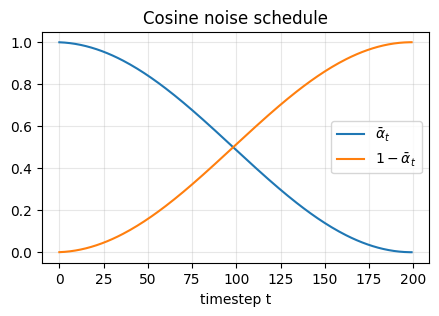

alpha_bar[0]  = 0.9997451305389404
alpha_bar[-1] = 6.071637415061559e-08


In [10]:
# 아래 값들은 sampling에서도 사용합니다.
alphas_cumprod_prev = torch.cat([torch.ones(1), alphas_cumprod[:-1]])
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)

posterior_variance = (
    betas * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)
).clamp_min(1e-20)
posterior_mean_coef1 = (
    betas * torch.sqrt(alphas_cumprod_prev) / (1.0 - alphas_cumprod)
)
posterior_mean_coef2 = (
    torch.sqrt(alphas) * (1.0 - alphas_cumprod_prev) / (1.0 - alphas_cumprod)
)

schedule_names = [
    "betas", "alphas", "alphas_cumprod", "alphas_cumprod_prev",
    "sqrt_alphas_cumprod", "sqrt_one_minus_alphas_cumprod",
    "posterior_variance", "posterior_mean_coef1", "posterior_mean_coef2",
]
for name in schedule_names:
    globals()[name] = globals()[name].to(device)

assert alphas.shape == (T,)
assert torch.all(alphas > 0) and torch.all(alphas < 1)
assert torch.all(alphas_cumprod[1:] < alphas_cumprod[:-1])

plt.figure(figsize=(5, 3))
plt.plot(alphas_cumprod.cpu(), label=r"$\bar{\alpha}_t$")
plt.plot((1 - alphas_cumprod).cpu(), label=r"$1-\bar{\alpha}_t$")
plt.xlabel("timestep t")
plt.legend()
plt.grid(alpha=0.3)
plt.title("Cosine noise schedule")
plt.show()

print("alpha_bar[0]  =", alphas_cumprod[0].item())
print("alpha_bar[-1] =", alphas_cumprod[-1].item())

## 4. TODO 3: Forward process

배치의 각 샘플은 서로 다른 timestep을 가질 수 있습니다. `extract`가 `(T,)` schedule에서 필요한 값을 골라 `(B,1,1,1)`로 바꿔 줍니다.

다음 closed form을 구현하세요.

$$z_t=\sqrt{\bar\alpha_t}z_0+\sqrt{1-\bar\alpha_t}\epsilon,\qquad \epsilon\sim\mathcal{N}(0,I)$$

In [11]:
def extract(a, t, x_shape):
    out = a.gather(0, t)
    return out.reshape(t.shape[0], *((1,) * (len(x_shape) - 1)))


def q_sample(z_0, t, noise=None):
    if noise is None:
        noise = torch.randn_like(z_0)

    # ------------------------------------------------------------------
    # TODO 3
    # timestep t에 해당되는 값: (B,1,1,1)
    sqrt_alpha_bar_t = extract(sqrt_alphas_cumprod, t, z_0.shape)
    sqrt_one_minus_alpha_bar_t = extract(
        sqrt_one_minus_alphas_cumprod, t, z_0.shape
    )
    z_t = sqrt_alpha_bar_t * z_0 + sqrt_one_minus_alpha_bar_t * noise
    if z_t is Ellipsis:
        raise NotImplementedError("TODO 3: z_t를 계산하세요")
    return z_t
    # ------------------------------------------------------------------

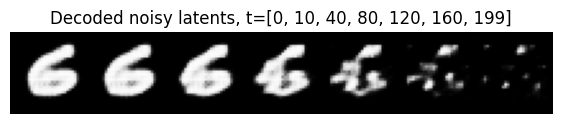

z_T mean=0.024, std=1.015


In [ ]:
z0 = latent_train[:8].to(device)
fixed_noise = torch.randn_like(z0)
forward_steps = [0, 10, 40, 80, 120, 160, T - 1]
noisy_decoded = []

autoencoder.eval()
with torch.no_grad():
    for step in forward_steps:
        t = torch.full((len(z0),), step, device=device, dtype=torch.long)
        # closed form으로 timestep t에서 noisy latent 샘플링 (no need for sequential modeling)
        zt = q_sample(z0, t, noise=fixed_noise)
        decoded = autoencoder.decode(denormalize_latent(zt))
        noisy_decoded.append(decoded[0:1].cpu())

show_images(torch.cat(noisy_decoded), f"Decoded noisy latents, t={forward_steps}", nrow=len(forward_steps))

t_last = torch.full((len(z0),), T - 1, device=device, dtype=torch.long)
z_last = q_sample(z0, t_last, noise=fixed_noise)
print(f"z_T mean={z_last.mean().item():.3f}, std={z_last.std().item():.3f}")

---
# Part 2. Classifier-Free Guidance

## 5. 조건부 noise predictor

모델은 noisy latent $z_t$, timestep $t$, class label $y$를 받아 noise를 예측합니다.
실제 LDM의 U-Net보다 훨씬 작지만, time embedding과 condition embedding을 각 residual block에 주입하는 핵심 구조는 같습니다.

`NULL_LABEL=10`은 condition이 없는 unconditional 입력을 뜻합니다.

In [ ]:
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, device=t.device).float() / (half - 1)
        )
        args = t.float().unsqueeze(1) * freqs.unsqueeze(0)
        return torch.cat([torch.sin(args), torch.cos(args)], dim=1)


class ConditionalResBlock(nn.Module):
    def __init__(self, channels, emb_dim):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, channels)
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1)
        self.emb_proj = nn.Linear(emb_dim, channels)
        self.norm2 = nn.GroupNorm(8, channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1)

    def forward(self, x, emb):
        h = self.conv1(F.silu(self.norm1(x)))
        h = h + self.emb_proj(F.silu(emb)).unsqueeze(-1).unsqueeze(-1)
        h = self.conv2(F.silu(self.norm2(h)))
        return x + h


# z_t, t, y를 입력으로 하여 noise 예측
class LatentDenoiser(nn.Module):
    def __init__(self, latent_channels=LATENT_CHANNELS, channels=64, emb_dim=128, n_blocks=5):
        super().__init__()
        self.time_mlp = nn.Sequential(
            # timestep 임베딩
            SinusoidalPosEmb(64),
            nn.Linear(64, emb_dim),
            nn.SiLU(),
            nn.Linear(emb_dim, emb_dim),
        )
        # label 임베딩
        self.label_emb = nn.Embedding(11, emb_dim)  # labels 0~9 + NULL_LABEL
        self.in_conv = nn.Conv2d(latent_channels, channels, 3, padding=1)
        self.blocks = nn.ModuleList([
            ConditionalResBlock(channels, emb_dim) for _ in range(n_blocks)
        ])
        self.out_norm = nn.GroupNorm(8, channels)
        self.out_conv = nn.Conv2d(channels, latent_channels, 3, padding=1)

    def forward(self, z_t, t, y):
        emb = self.time_mlp(t) + self.label_emb(y)
        h = self.in_conv(z_t)
        for block in self.blocks:
            h = block(h, emb)
        return self.out_conv(F.silu(self.out_norm(h)))


denoiser = LatentDenoiser().to(device)
print(f"denoiser parameters: {sum(p.numel() for p in denoiser.parameters()):,}")

with torch.no_grad():
    dummy_z = torch.randn(4, LATENT_CHANNELS, 7, 7, device=device)
    dummy_t = torch.randint(0, T, (4,), device=device)
    dummy_y = torch.randint(0, 11, (4,), device=device)
    assert denoiser(dummy_z, dummy_t, dummy_y).shape == dummy_z.shape
print("shape test passed")

denoiser parameters: 442,884
shape test passed


## 6. TODO 4: CFG를 위한 condition dropout

CFG는 별도 classifier 없이 한 모델이 conditional과 unconditional 예측을 모두 배우게 합니다.
학습 중 확률 `COND_DROP_PROB`만큼 label을 `NULL_LABEL`로 바꾸세요.

1. $t$와 noise $\epsilon$을 뽑는다.
2. `q_sample`로 $z_t$를 만든다.
3. 일부 label을 `NULL_LABEL`로 교체한다.
4. 모델의 noise 예측과 실제 noise 사이 MSE를 반환한다.

In [14]:
def diffusion_loss(model, z_0, labels):
    batch_size = z_0.size(0)
    t = torch.randint(0, T, (batch_size,), device=z_0.device, dtype=torch.long)
    noise = torch.randn_like(z_0)
    z_t = q_sample(z_0, t, noise=noise)

    # ------------------------------------------------------------------
    # TODO 4
    # Step 3 & 4

    labels_in = labels.clone()
    # 샘플마다 [0,1) uniform distribution으로 부터 rand 생성
    # 0.15을 기준으로 masking 생성
    # 15% 확률로 mask
    # Goal: 하나의 모델이 조건/비조건 예측을 모두 학습
    drop_mask = torch.rand(batch_size, device=labels.device) < COND_DROP_PROB
    if drop_mask is Ellipsis:
        raise NotImplementedError("TODO 4-a: drop_mask를 만드세요")

    # mask = class 10
    labels_in[drop_mask] = NULL_LABEL
    pred_noise = model(z_t, t, labels_in)
    loss = F.mse_loss(pred_noise, noise)
    if loss is Ellipsis:
        raise NotImplementedError("TODO 4-b: noise prediction loss를 계산하세요")
    # ------------------------------------------------------------------

    return loss, drop_mask.float().mean()

## 7. Denoiser 학습

샘플링에는 학습 모델의 EMA(Exponential Moving Average)를 사용합니다. EMA는 update마다 흔들리는 파라미터를 완만하게 평균내 생성 품질을 안정화합니다.
이 셀은 수정하지 않고 실행하세요.

[LDM] update 0001/3000 | loss 1.0685 | condition drop 0.12
[LDM] update 0500/3000 | loss 0.1276 | condition drop 0.16
[LDM] update 1000/3000 | loss 0.1084 | condition drop 0.15
[LDM] update 1500/3000 | loss 0.1013 | condition drop 0.16
[LDM] update 2000/3000 | loss 0.0973 | condition drop 0.17
[LDM] update 2500/3000 | loss 0.0938 | condition drop 0.14
[LDM] update 3000/3000 | loss 0.0918 | condition drop 0.13
Diffusion training time: 601.7s
Total training time    : 624.4s


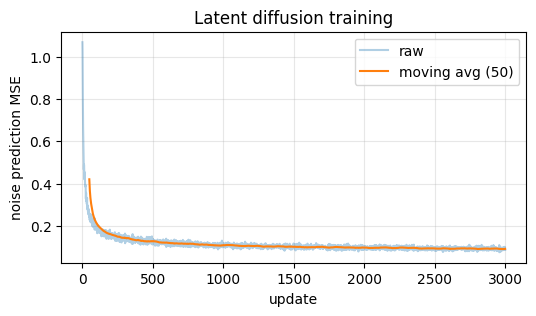

In [15]:
optimizer = torch.optim.AdamW(denoiser.parameters(), lr=1e-3, weight_decay=1e-4)
ema_denoiser = copy.deepcopy(denoiser).eval()
for p in ema_denoiser.parameters():
    p.requires_grad_(False)

loss_history = []
data_iter = iter(latent_loader)
log_every = 20 if QUICK_MODE else 500
train_start = sync_time()

for step in range(1, DIFF_TRAIN_STEPS + 1):
    try:
        z_0, labels = next(data_iter)
    except StopIteration:
        data_iter = iter(latent_loader)
        z_0, labels = next(data_iter)

    z_0 = z_0.to(device, non_blocking=True)
    labels = labels.to(device, non_blocking=True)
    loss, drop_ratio = diffusion_loss(denoiser, z_0, labels)

    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(denoiser.parameters(), 1.0)
    optimizer.step()

    # 초반에는 빠르게 따라가고, 이후 decay를 0.995까지 높입니다.
    decay = min(0.995, (1 + step) / (10 + step))
    with torch.no_grad():
        for ema_p, p in zip(ema_denoiser.parameters(), denoiser.parameters()):
            ema_p.mul_(decay).add_(p, alpha=1 - decay)

    loss_history.append(loss.item())
    if step % log_every == 0 or step == 1:
        recent = np.mean(loss_history[-min(100, len(loss_history)):])
        print(f"[LDM] update {step:04d}/{DIFF_TRAIN_STEPS} | loss {recent:.4f} | "
              f"condition drop {drop_ratio.item():.2f}")

diff_seconds = sync_time() - train_start
print(f"Diffusion training time: {diff_seconds:.1f}s")
print(f"Total training time    : {ae_seconds + diff_seconds:.1f}s")

plt.figure(figsize=(6, 3))
plt.plot(loss_history, alpha=0.35, label="raw")
if len(loss_history) >= 50:
    smooth = np.convolve(loss_history, np.ones(50) / 50, mode="valid")
    plt.plot(range(49, len(loss_history)), smooth, label="moving avg (50)")
plt.xlabel("update")
plt.ylabel("noise prediction MSE")
plt.title("Latent diffusion training")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 8. TODO 5: Classifier-Free Guidance

추론에서는 같은 $z_t,t$에 대해 두 예측을 얻습니다.

- $\epsilon_{uncond}=\epsilon_\theta(z_t,t,\varnothing)$
- $\epsilon_{cond}=\epsilon_\theta(z_t,t,y)$

이 노트북은 다음 convention을 사용합니다.

$$
\epsilon_{cfg}=\epsilon_{uncond}+w(\epsilon_{cond}-\epsilon_{uncond})
$$

- $w=0$: unconditional
- $w=1$: ordinary conditional
- $w>1$: condition을 더 강하게 반영

두 배치를 이어 붙여 모델을 한 번 호출하는 방식으로 구현하세요.

In [16]:
@torch.no_grad()
def predict_noise_cfg(model, z_t, t, labels, guidance_scale):
    null_labels = torch.full_like(labels, NULL_LABEL)

    # concat을 통해 uncond/cond를 한번만 호출
    z_both = torch.cat([z_t, z_t], dim=0)
    t_both = torch.cat([t, t], dim=0)
    labels_both = torch.cat([null_labels, labels], dim=0)
    eps_uncond, eps_cond = model(z_both, t_both, labels_both).chunk(2, dim=0)

    # ------------------------------------------------------------------
    # TODO 5
    # 조건을 넣었을 때 예측이 조건이 없을 때 예측에서 얼마나, 어느 방향으로 달라지는가
    cfg_direction = eps_cond - eps_uncond
    guided_noise = eps_uncond + guidance_scale * cfg_direction
    if guided_noise is Ellipsis:
        raise NotImplementedError("TODO 5: guided_noise를 계산하세요")
    return guided_noise
    # ------------------------------------------------------------------

In [17]:
ema_denoiser.eval()
test_z = torch.randn(4, LATENT_CHANNELS, 7, 7, device=device)
test_t = torch.randint(0, T, (4,), device=device)
test_y = torch.tensor([1, 3, 5, 7], device=device)
null_y = torch.full_like(test_y, NULL_LABEL)

with torch.no_grad():
    eps_u = ema_denoiser(test_z, test_t, null_y)
    eps_c = ema_denoiser(test_z, test_t, test_y)
    # w=0: uncond
    eps_w0 = predict_noise_cfg(ema_denoiser, test_z, test_t, test_y, 0.0)
    # w=1: cond
    eps_w1 = predict_noise_cfg(ema_denoiser, test_z, test_t, test_y, 1.0)

assert torch.allclose(eps_w0, eps_u, atol=1e-5), "w=0은 unconditional 예측이어야 합니다."
assert torch.allclose(eps_w1, eps_c, atol=1e-5), "w=1은 conditional 예측이어야 합니다."
print("CFG endpoint tests passed")

CFG endpoint tests passed


---
# Part 3. DDPM vs. DDIM Sampling

## 9. TODO 6: Noise에서 clean latent 예측

Forward 식을 $z_0$에 대해 정리하면 다음과 같습니다.

$$
\hat z_0=\frac{z_t-\sqrt{1-\bar\alpha_t}\,\epsilon_\theta(z_t,t,y)}{\sqrt{\bar\alpha_t}}
$$

In [18]:
# TODO3의 forward closed form을 정리
# epsilon 대신 pred_noise를 대입 (=z0_pred)
# pred_noise를 원본 noise로 convert
def predict_x0_from_eps(z_t, t, pred_noise):
    # ------------------------------------------------------------------
    # TODO 6
    sqrt_alpha_bar_t = extract(sqrt_alphas_cumprod, t, z_t.shape)
    sqrt_one_minus_alpha_bar_t = extract(
        sqrt_one_minus_alphas_cumprod, t, z_t.shape
    )
    z0_pred = (z_t - sqrt_one_minus_alpha_bar_t * pred_noise) / sqrt_alpha_bar_t
    if z0_pred is Ellipsis:
        raise NotImplementedError("TODO 6: z0_pred를 계산하세요")
    return z0_pred
    # ------------------------------------------------------------------

## 10. DDPM sampler (실행만)

DDPM은 모든 timestep `199, 198, ..., 0`을 순서대로 방문합니다. 아래 구현은 posterior mean과 variance로 ancestral sampling을 수행합니다.

In [19]:
@torch.no_grad()
def ddpm_sample(model, labels, guidance_scale=3.0, initial_noise=None):
    model.eval()
    labels = labels.to(device)
    batch_size = len(labels)

    if initial_noise is None:
        z = torch.randn(batch_size, LATENT_CHANNELS, 7, 7, device=device)
    else:
        z = initial_noise.clone().to(device)

    for t_index in reversed(range(T)):
        t = torch.full((batch_size,), t_index, device=device, dtype=torch.long)
        pred_noise = predict_noise_cfg(model, z, t, labels, guidance_scale)
        z0_pred = predict_x0_from_eps(z, t, pred_noise).clamp(-4, 4)

        coef1 = extract(posterior_mean_coef1, t, z.shape)
        coef2 = extract(posterior_mean_coef2, t, z.shape)
        model_mean = coef1 * z0_pred + coef2 * z

        if t_index > 0:
            variance = extract(posterior_variance, t, z.shape)
            z = model_mean + torch.sqrt(variance) * torch.randn_like(z)
        else:
            z = model_mean

    return z


@torch.no_grad()
def decode_latents(z_norm):
    autoencoder.eval()
    return autoencoder.decode(denormalize_latent(z_norm)).clamp(0, 1)

## 11. TODO 7, 8: DDIM 한 스텝

DDIM은 학습을 다시 하지 않고 같은 noise predictor를 사용합니다. 현재 timestep $t$에서 건너뛸 이전 timestep $s<t$로 이동할 때:

$$
\sigma_t=\eta\sqrt{\frac{1-\bar\alpha_s}{1-\bar\alpha_t}
\left(1-\frac{\bar\alpha_t}{\bar\alpha_s}\right)}
$$

$$
z_s=\sqrt{\bar\alpha_s}\hat z_0
+\sqrt{1-\bar\alpha_s-\sigma_t^2}\,\epsilon_\theta(z_t,t,y)
+\sigma_t\epsilon
$$

- `eta=0`: noise 항이 사라지는 deterministic DDIM
- `eta>0`: stochasticity를 추가
- 마지막의 `prev_t_index=-1`은 $\bar\alpha_s=1$인 clean latent를 뜻합니다.

In [20]:
@torch.no_grad()
def ddim_step(
    model, z_t, t_index, prev_t_index, labels,
    guidance_scale=3.0, eta=0.0,
):
    batch_size = len(labels)
    t = torch.full((batch_size,), t_index, device=z_t.device, dtype=torch.long)
    pred_noise = predict_noise_cfg(model, z_t, t, labels, guidance_scale)
    z0_pred = predict_x0_from_eps(z_t, t, pred_noise).clamp(-4, 4)

    alpha_bar_t = alphas_cumprod[t_index]
    alpha_bar_prev = (
        torch.tensor(1.0, device=z_t.device)
        if prev_t_index < 0
        else alphas_cumprod[prev_t_index]
    )

    # ------------------------------------------------------------------
    # TODO 7
    # alpha_bar_prev = alpha_s
    variance_ratio = (1 - alpha_bar_prev) / (1 - alpha_bar_t)
    skip_ratio = 1 - alpha_bar_t / alpha_bar_prev
    sigma_t = eta * torch.sqrt(variance_ratio * skip_ratio)
    if sigma_t is Ellipsis:
        raise NotImplementedError("TODO 7: sigma_t를 계산하세요")
    # ------------------------------------------------------------------

    # ------------------------------------------------------------------
    # TODO 8
    direction_coef = torch.sqrt(
        (1 - alpha_bar_prev - sigma_t ** 2).clamp(min=0)
    )
    # z_t에서 원본 노이즈로의 방향
    direction = direction_coef * pred_noise
    if direction is Ellipsis:
        raise NotImplementedError("TODO 8-a: direction을 계산하세요")

    noise = (
        torch.randn_like(z_t)
        if prev_t_index >= 0
        else torch.zeros_like(z_t)
    )
    # 1st term: TODO6에서 추정한 clean latent in timestep s에서의 scale
    # 2nd term: noise_pred의 방향 (z_t와의 consistency 유지)
    # 3rd term: eta > 0에서만 활성화
    # prev_t_index < 0에서는 noise = torch.zeros_like(z_t)
    z_prev = torch.sqrt(alpha_bar_prev) * z0_pred + direction + sigma_t * noise
    if z_prev is Ellipsis:
        raise NotImplementedError("TODO 8-b: z_prev를 계산하세요")
    # ------------------------------------------------------------------

    return z_prev

In [21]:
def make_ddim_timesteps(n_steps):
    if not 2 <= n_steps <= T:
        raise ValueError(f"n_steps must be between 2 and {T}")
    return torch.linspace(T - 1, 0, n_steps).round().long().unique_consecutive().tolist()


@torch.no_grad()
def ddim_sample(
    model, labels, n_steps=25, guidance_scale=3.0,
    eta=0.0, initial_noise=None,
):
    model.eval()
    labels = labels.to(device)
    batch_size = len(labels)

    if initial_noise is None:
        z = torch.randn(batch_size, LATENT_CHANNELS, 7, 7, device=device)
    else:
        z = initial_noise.clone().to(device)

    timesteps = make_ddim_timesteps(n_steps)
    for i, t_index in enumerate(timesteps):
        prev_t_index = timesteps[i + 1] if i + 1 < len(timesteps) else -1
        z = ddim_step(
            model, z, t_index, prev_t_index, labels,
            guidance_scale=guidance_scale, eta=eta,
        )
    return z

In [22]:
# eta=0이고 initial noise가 같으면 완전히 같은 결과가 나와야 합니다.
det_labels = torch.tensor([0, 1, 2, 3], device=device)
det_noise = torch.randn(4, LATENT_CHANNELS, 7, 7, device=device)

z_a = ddim_sample(ema_denoiser, det_labels, n_steps=10, eta=0.0, initial_noise=det_noise)
z_b = ddim_sample(ema_denoiser, det_labels, n_steps=10, eta=0.0, initial_noise=det_noise)
assert torch.allclose(z_a, z_b, atol=1e-6), "eta=0 DDIM은 같은 initial noise에서 deterministic해야 합니다."
print("DDIM deterministic test passed")

DDIM deterministic test passed


---
# Part 4. Experiments

## 12. CFG scale 비교

모든 행이 **같은 initial noise**에서 시작합니다. 따라서 행 사이의 차이는 guidance scale에서 옵니다.
각 열 위의 숫자가 목표 class입니다.

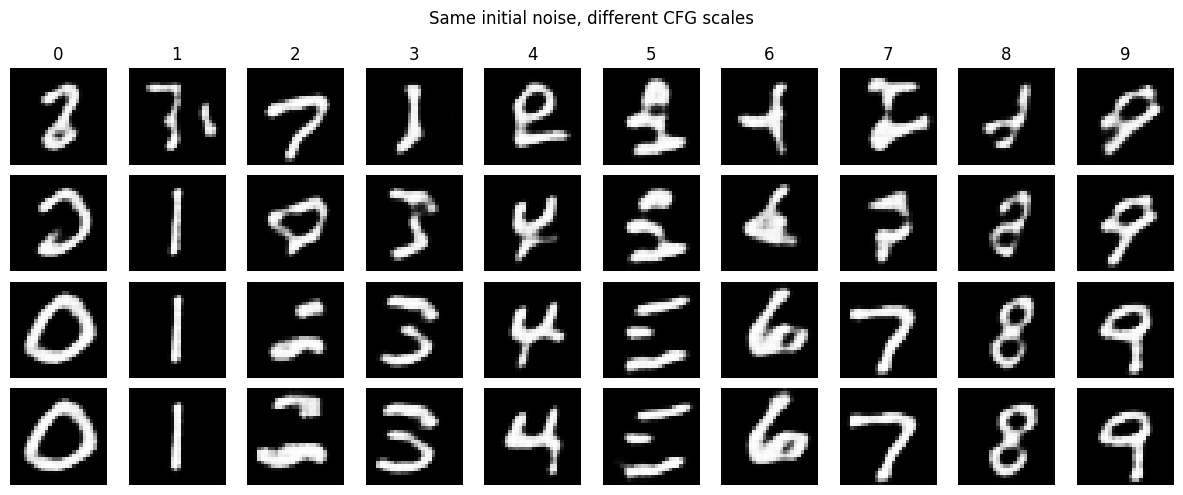

In [23]:
labels_grid = torch.arange(10, device=device)
shared_noise = torch.randn(10, LATENT_CHANNELS, 7, 7, device=device)
guidance_scales = [0.0, 1.0, 3.0, 5.0]

fig, axes = plt.subplots(len(guidance_scales), 10, figsize=(12, 5))
for row, scale in enumerate(guidance_scales):
    z_gen = ddim_sample(
        ema_denoiser, labels_grid, n_steps=25,
        guidance_scale=scale, eta=0.0, initial_noise=shared_noise,
    )
    images = decode_latents(z_gen).cpu()
    for col in range(10):
        axes[row, col].imshow(images[col, 0], cmap="gray", vmin=0, vmax=1)
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(str(col))
    axes[row, 0].set_ylabel(f"w={scale:g}", rotation=0, labelpad=18, va="center")

plt.suptitle("Same initial noise, different CFG scales")
plt.tight_layout()
plt.show()

## 13. DDIM step 수 비교

이번에도 같은 initial noise와 `guidance_scale=3`을 사용합니다. step 수를 줄일수록 모델 호출은 줄지만, 너무 적으면 형태가 무너질 수 있습니다.

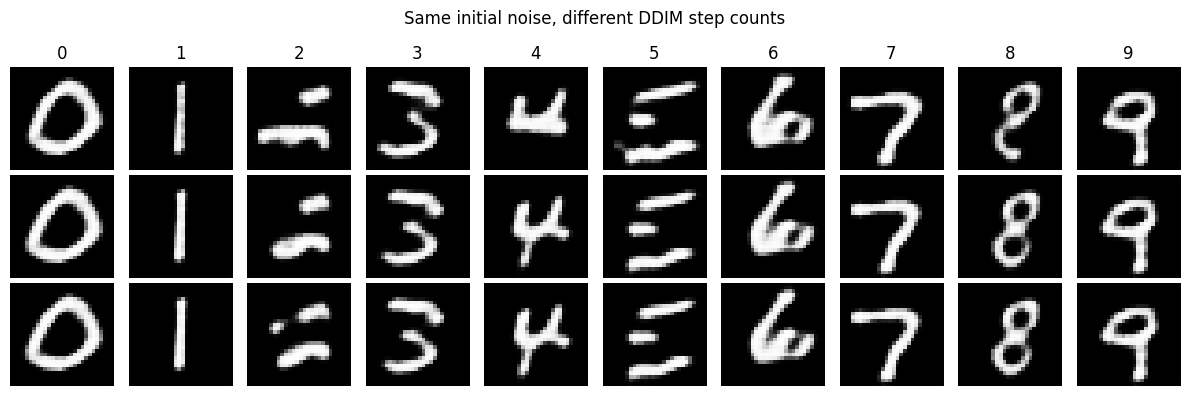

In [24]:
ddim_steps_list = [10, 25, 50]
fig, axes = plt.subplots(len(ddim_steps_list), 10, figsize=(12, 4))

for row, n_steps in enumerate(ddim_steps_list):
    z_gen = ddim_sample(
        ema_denoiser, labels_grid, n_steps=n_steps,
        guidance_scale=3.0, eta=0.0, initial_noise=shared_noise,
    )
    images = decode_latents(z_gen).cpu()
    for col in range(10):
        axes[row, col].imshow(images[col, 0], cmap="gray", vmin=0, vmax=1)
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(str(col))
    axes[row, 0].set_ylabel(f"{n_steps} steps", rotation=0, labelpad=28, va="center")

plt.suptitle("Same initial noise, different DDIM step counts")
plt.tight_layout()
plt.show()

## 14. Sampling 시간 비교

CFG 내부에서는 conditional/unconditional 두 예측이 필요하지만, 배치를 합쳐 코드상 denoiser를 step당 한 번 호출합니다.
아래 표의 `denoiser calls`는 timestep update 횟수입니다.

In [25]:
benchmark_labels = torch.arange(10, device=device)
benchmark_noise = torch.randn(10, LATENT_CHANNELS, 7, 7, device=device)
benchmark_rows = []

def benchmark(name, calls, fn):
    start = sync_time()
    z_out = fn()
    elapsed = sync_time() - start
    benchmark_rows.append((name, calls, elapsed))
    return z_out


_ = benchmark(
    "DDPM", T,
    lambda: ddpm_sample(
        ema_denoiser, benchmark_labels,
        guidance_scale=3.0, initial_noise=benchmark_noise,
    ),
)
for n_steps in [10, 25, 50]:
    _ = benchmark(
        f"DDIM-{n_steps}", n_steps,
        lambda n_steps=n_steps: ddim_sample(
            ema_denoiser, benchmark_labels, n_steps=n_steps,
            guidance_scale=3.0, eta=0.0, initial_noise=benchmark_noise,
        ),
    )

print(f"{'sampler':<10} | {'denoiser calls':>14} | {'seconds':>9} | {'vs DDPM':>8}")
print("-" * 52)
ddpm_time = benchmark_rows[0][2]
for name, calls, elapsed in benchmark_rows:
    print(f"{name:<10} | {calls:>14} | {elapsed:>9.3f} | {ddpm_time / elapsed:>7.2f}x")

sampler    | denoiser calls |   seconds |  vs DDPM
----------------------------------------------------
DDPM       |            200 |     1.850 |    1.00x
DDIM-10    |             10 |     0.085 |   21.76x
DDIM-25    |             25 |     0.213 |    8.70x
DDIM-50    |             50 |     0.458 |    4.04x


---
# Part 5. 생각해 볼 질문: 무엇을 예측하는 것이 좋을까?

이번 실습에서 모델은 noisy latent를 입력받아 **섞인 noise**를 예측했습니다. 하지만 생성 모델은 다음처럼 서로 다른 대상을 예측하도록 만들 수도 있습니다.

- **원본 예측 ($x_0$)**: noise가 섞이기 전의 깨끗한 데이터를 예측
- **noise 예측 ($\epsilon$)**: 데이터에 섞인 noise를 예측 — 이번 실습의 방식
- **score 예측**: noisy data를 더 자연스러운 데이터 쪽으로 움직일 방향을 예측
- **velocity 예측**: noise에서 데이터로 이동하는 방향을 예측 — 다음 주 flow matching과 연결

이 값들은 수식으로 서로 바꿀 수 있지만, 모델이 무엇을 **직접** 예측하느냐에 따라 학습 난이도는 달라질 수 있습니다. [*Back to Basics: Let Denoising Generative Models Denoise*](https://arxiv.org/abs/2511.13720)는 상황에 따라 noise보다 원본을 직접 예측하는 방식이 더 쉬울 수 있다고 설명합니다.

> **생각해 볼 질문**  
> 여러분이 모델을 만든다면 **원본, noise, score 중 무엇을 직접 예측하게 하고 싶은가요?** 하나를 고르고 그 이유를 자유롭게 작성해 주세요. 이번 실습처럼 작은 latent를 사용할 때와 큰 원본 이미지를 사용할 때 선택이 달라질지도 함께 생각해 봅시다. 다음 시간에 score-based model과 flow matching을 배운 뒤에는 지금의 생각과 비교해 보세요.

### 나의 생각

저라면 noise($\epsilon$)보다는 원본($x_0$)을 직접 예측하는 방향을 선택하고 싶습니다.

loss curve를 보면 학습 초반 500 step 안에 loss가 1.07 → 0.13으로 대부분 떨어지고, 이후 2500 step 동안은 0.13 → 0.09 정도로 매우 완만하게만 줄어듭니다. 초반의 급격한 하락은 아마 "대충 노이즈처럼 보이는 것"만 맞춰도 MSE가 크게 줄어드는 구간이고, 이후의 완만한 구간은 실제로 원본 구조를 복원하는 데 필요한 미세한 신호를 맞추는 구간일 것입니다. 즉 $\epsilon$을 직접 타깃으로 두면, 모델이 "노이즈다운 것"과 "원본 정보가 담긴 잔차"를 분리해서 학습해야 하는 부담이 뒤늦게, 그리고 천천히 해소된다는 인상을 받았습니다. 반대로 $x_0$를 직접 예측하게 하면 손실 함수가 처음부터 "복원해야 할 대상 그 자체"를 향하므로, 특히 $t$가 작아 원본 신호가 아직 많이 남아있는 구간에서는 학습 신호가 직접적이고 명확할 것 같습니다.

또한 DDIM step 수 비교와 sampling 시간 비교를 보면, step 수를 200(DDPM) → 50 → 25 → 10으로 크게 줄여도 파이프라인이 정상 동작합니다. 이렇게 적은 step만 거칠 때는 각 step에서 모델이 예측한 값의 오차가 누적될 여지가 큽니다. `predict_x0_from_eps`(TODO 6)에서 보았듯, 실제 샘플링 계산은 결국 $\epsilon$을 다시 $\hat z_0$로 변환해서 사용하는데, 이 변환은 $\sqrt{\bar\alpha_t}$로 나누는 형태라 $t$가 클수록(초반 denoising step일수록) 작은 $\epsilon$ 오차가 크게 증폭됩니다. step 수가 적어 각 step이 더 큰 구간을 건너뛰어야 하는 상황에서는, 모델이 애초에 $x_0$를 직접 예측하도록 학습되어 있으면 이런 증폭 문제를 우회할 수 있어 더 안정적일 것이라고 생각합니다.

정리하면, 이번처럼 작은 latent($4\times7\times7$)를 짧은 $T=200$으로 다루는 세팅에서는 $\epsilon$ 예측도 충분히 잘 동작했지만, 만약 step 수를 더 공격적으로 줄이거나(few-step/1-step 샘플링) 더 큰 원본 이미지로 확장한다면 $x_0$ 예측 쪽이 변환 과정에서 생기는 오차 증폭 문제로부터 자유로울 것 같아 그 방향을 선호합니다.

---
## 제출 전 체크리스트

- [✔️] TODO 1~8을 모두 채웠다
- [✔️] Colab의 T4 GPU에서 `런타임 > 세션 다시 시작 및 모두 실행`을 완료했다
- [✔️] AE reconstruction, loss curve, CFG 비교, DDIM step 비교, runtime 표가 출력에 남아 있다
- [✔️] CFG endpoint test와 DDIM deterministic test를 통과했다
- [✔️] 생각해 볼 질문에 대한 나의 생각을 작성했다
- [✔️] 파일명을 본인의 기수와 이름으로 바꿨다

`KUBIG_26_FALL/Basic Study/CV/week5`에 제출 / 마감은 운영진 공지 확인